<h1>Tarea 1. Analisis de Algoritmos <h1>
<h4>Autor: Miranda Sanchez Javier Leonardo<h4>
<h4>Matricula: 223215039<h4>


En este notebook se analizan experimentalmente tres algoritmos de ordenamiento <b>Insertion Sort</b>, <b>Selection Sort</b> y <b>Merge Sort</b>. El objetivo es estudiar su comportamiento en terminos de tiempo de ejecucion al aplicarlos sobre arreglos de longitud $n$

Con el fin de facilitar el trabajo, se implementaron funciones auxiliares que permiten generar las muestras de dados, medir los tiempos de ejecucion y graficar los resultados obtenidos

In [27]:
#Bibliotecas a utilizar.
import random
import time
import matplotlib.pyplot as plt
import math
import numpy as np

<h1>Creacion de muestras.<h1>

In [14]:
#Creacion de las muestras a utilizar para los algoritmos (MEJOR CASO).
def creacion_muestra_mejor_caso(n):
    n += 1
    muestra_mejor_caso = []

    for i in range(1, n):
        muestra_mejor_caso.append(i)
    
    return muestra_mejor_caso

#Creacion de las muestras a utilizar para los algoritmos (PEOR CASO).
def creacion_muestra_peor_caso(n):
    n += 1
    muestra_peor_caso = []

    for i in range(1, n):
        muestra_peor_caso.append(n - i)
    
    return muestra_peor_caso

#Creacion de las muestras a utilizar para los algoritmos (CASO PROMEDIO).
def creacion_muestras_caso_promedio(n):

    muestra_caso_promedio = []
    muestra_caso_promedio = random.sample(range(1,n + 1), n)

    return muestra_caso_promedio


<h1>Codificacion de algoritmos de ordenamiento.<h1>

In [15]:
#Codificacion del algoritmo INSERTION-SORT
def INSERTION_SORT(array):
    inicio = time.perf_counter()

    for j in range(1, len(array)):
        key = array[j]
        i = j - 1
        while i >= 0 and array[i] > key:
            array[i + 1] = array[i]
            i = i - 1
        array[i + 1] = key
    
    fin = time.perf_counter()
    tiempo = (fin - inicio) * 1000
    return array, tiempo

#Codificacion del aloritmo SELECTION-SORT
def SELECTION_SORT(array):
    inicio = time.perf_counter()

    for i in range(0, len(array) - 1):
        min_j = i
        min_x = array[i]
        for j in range (i + 1, len(array)):
            if (array[j] < min_x):
                min_j = j
                min_x = array[j]
        array[min_j] = array[i]
        array[i] = min_x
    

    fin = time.perf_counter()
    tiempo = (fin - inicio) * 1000
    return array, tiempo

#Codificacion del algoritmo MERGE-SORT
def MERGE_SORT(array):

    def merge_sort(array, p, r):
        if p < r:
            q = math.floor((p + r) / 2)
            merge_sort(array, p, q)
            merge_sort(array, q + 1,r)
            merge(array, p, q, r)

    def merge(A, p, q, r):
        L = A[p:q+1]+[float('inf')]
        R = A[q+1:r+1]+[float('inf')]
        i = 0
        j = 0
        for k in range(p, r + 1):

            if L[i] <= R[j]:
                A[k] = L[i]
                i += 1
            else:
                A[k] = R[j]
                j += 1

    inicio = time.perf_counter()
    merge_sort(array, 0, len(array) - 1)
    fin = time.perf_counter()
    tiempo = (fin - inicio) * 1000
    
    return array, tiempo
    


In [16]:
SELECTION_SORT([5,4,3,2,1])

([1, 2, 3, 4, 5], 0.007774999971843499)

<h1>Funcion para graficar el tiempo respecto a la longitud de n.<h1>

In [17]:
def graficar(tam, mejor, promedio, peor, algoritmo):

    plt.figure(figsize=(8,5))

    # Mejor caso
    plt.plot(tam, mejor, 'o-', label="Mejor caso")

    # Caso promedio
    plt.plot(tam, promedio, 'o-', label="Caso promedio")

    # Peor caso
    plt.plot(tam, peor, 'o-', label="Peor caso")

    plt.xlabel("Tamaño del array (n)")
    plt.ylabel("Tiempo (ms)")
    plt.title(f"Análisis de complejidad del algoritmo: {algoritmo}")

    plt.legend()
    plt.grid(True)

    plt.show()



<h1>Graficas de los algoritmos.<h1>

In [52]:
tam = []
tiem_mejor = []
tiem_prom = []
tiem_peor = []


for n in range(1, 11):

    size = n * 1000
    tam.append(size)

    _, t_mejor = INSERTION_SORT(creacion_muestra_mejor_caso(size))
    _, t_peor = INSERTION_SORT(creacion_muestra_peor_caso(size))
    _, t_prom = INSERTION_SORT(creacion_muestras_caso_promedio(size))

    tiem_mejor.append(t_mejor)
    tiem_peor.append(t_peor)
    tiem_prom.append(t_prom)


print(f"{'Tam':<10}{'Mejor Caso':<15}{'Promedio':<15}{'Peor Caso':<15}")
for t, mejor, prom, peor in zip(tam, tiem_mejor, tiem_prom, tiem_peor):
    print(f"{t:<10}{mejor:<15.6f}{prom:<15.6f}{peor:<15.6f}")

Tam       Mejor Caso     Promedio       Peor Caso      
1000      0.111806       19.640270      45.886277      
2000      0.199915       53.304843      112.173071     
3000      0.262032       126.046408     254.620352     
4000      0.346467       224.083206     450.359770     
5000      0.379699       351.786472     727.565228     
6000      0.467632       493.577789     1020.720722    
7000      0.560497       667.144657     1388.663933    
8000      0.599224       878.169696     1794.602805    
9000      0.679688       1122.592561    2352.177972    
10000     0.812760       1410.292153    2830.567363    


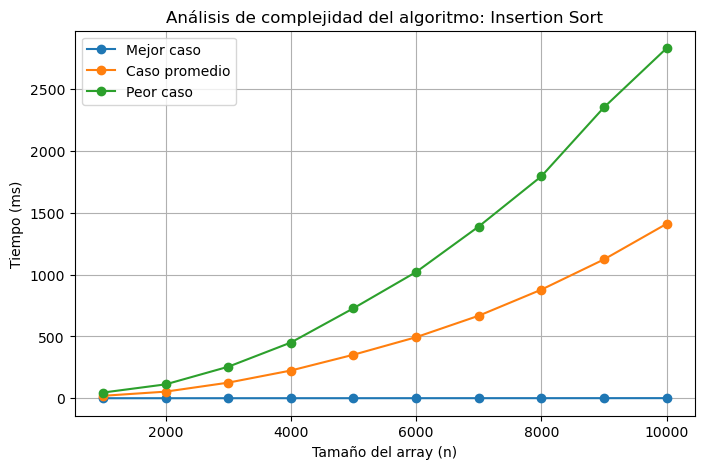

In [55]:
graficar(tam, tiem_mejor,tiem_prom, tiem_peor, "Insertion Sort")

<h1>Ajuste de curvas: Insertion Sort<h1>

Mejor caso
Ajuste lineal: T(n) = 7.323018e-05n + 3.920600e-02
Ajuste cuadrático: T(n) = 1.269432e-09n^2 + 5.926643e-05n + 6.713350e-02



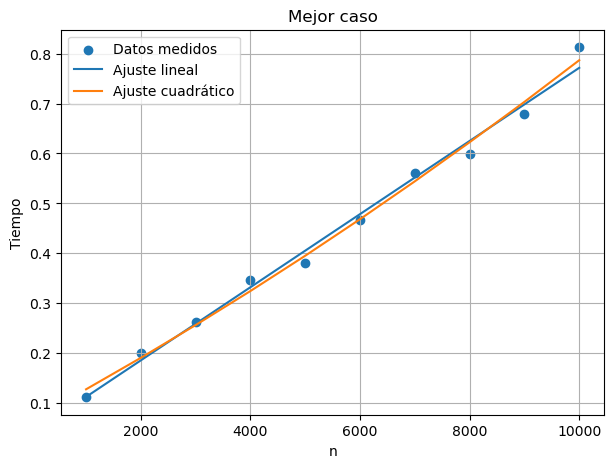

Caso promedio
Ajuste lineal: T(n) = 1.529241e-01n + -3.064186e+02
Ajuste cuadrático: T(n) = 1.466679e-05n^2 + -8.410613e-03n + 1.625075e+01



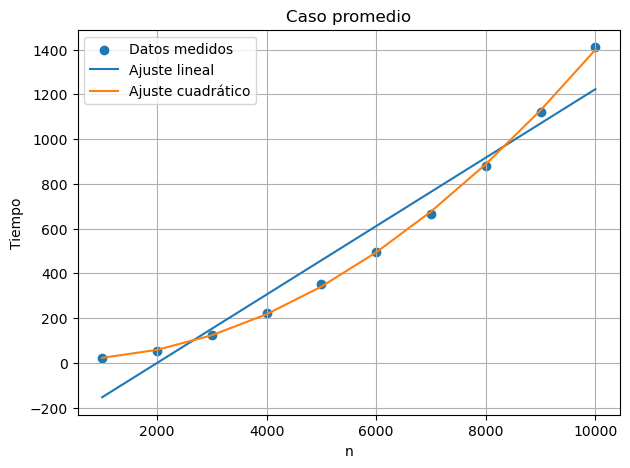

Peor caso
Ajuste lineal: T(n) = 3.124251e-01n + -6.206044e+02
Ajuste cuadrático: T(n) = 2.889389e-05n^2 + -5.407627e-03n + 1.506109e+01



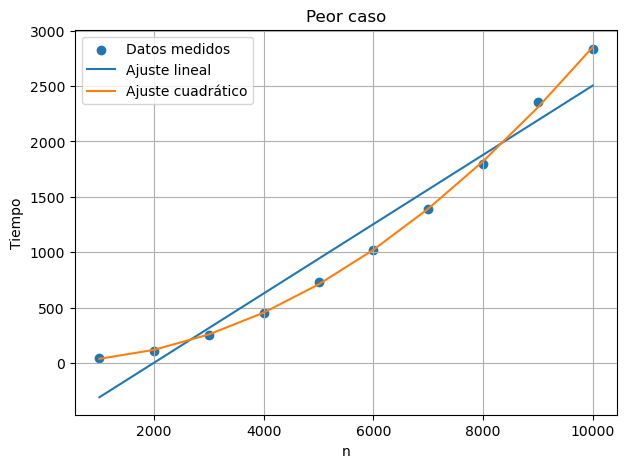

In [57]:

n = np.array(tam)

casos = {
    "Mejor caso": np.array(tiem_mejor),
    "Caso promedio": np.array(tiem_prom),
    "Peor caso": np.array(tiem_peor)
}

for nombre, t in casos.items():

    coef_lin = np.polyfit(n, t, 1)
    a, b = coef_lin
    T_lin = a*n + b

    coef_cuad = np.polyfit(n, t, 2)
    a2, b2, c2 = coef_cuad
    T_cuad = a2*n**2 + b2*n + c2

    print(nombre)
    print(f"Ajuste lineal: T(n) = {a:.6e}n + {b:.6e}")
    print(f"Ajuste cuadrático: T(n) = {a2:.6e}n^2 + {b2:.6e}n + {c2:.6e}")
    print()

    plt.figure(figsize=(7,5))

    plt.scatter(n, t, label="Datos medidos")
    plt.plot(n, T_lin, label="Ajuste lineal")
    plt.plot(n, T_cuad, label="Ajuste cuadrático")

    plt.xlabel("n")
    plt.ylabel("Tiempo")
    plt.title(nombre)

    plt.legend()
    plt.grid(True)

    plt.show()

In [58]:
tam = []
tiem_mejor = []
tiem_prom = []
tiem_peor = []

for n in range(1, 11):

    size = n * 1000
    tam.append(size)

    _, t_mejor = SELECTION_SORT(creacion_muestra_mejor_caso(size))
    _, t_peor = SELECTION_SORT(creacion_muestra_peor_caso(size))
    _, t_prom = SELECTION_SORT(creacion_muestras_caso_promedio(size))

    tiem_mejor.append(t_mejor)
    tiem_peor.append(t_peor)
    tiem_prom.append(t_prom)

print(f"{'Tam':<10}{'Mejor Caso':<15}{'Promedio':<15}{'Peor Caso':<15}")
for t, mejor, prom, peor in zip(tam, tiem_mejor, tiem_prom, tiem_peor):
    print(f"{t:<10}{mejor:<15.6f}{prom:<15.6f}{peor:<15.6f}")

Tam       Mejor Caso     Promedio       Peor Caso      
1000      18.353155      13.470287      21.097366      
2000      51.038534      53.075983      62.839981      
3000      115.307636     119.032789     145.908210     
4000      205.999498     228.196150     258.171683     
5000      322.418640     339.419892     400.394058     
6000      467.923316     471.308311     564.409402     
7000      619.817787     643.691376     758.128177     
8000      809.103389     844.129225     988.229234     
9000      1016.295566    1090.679949    1252.704989    
10000     1255.739752    1330.041518    1541.485682    


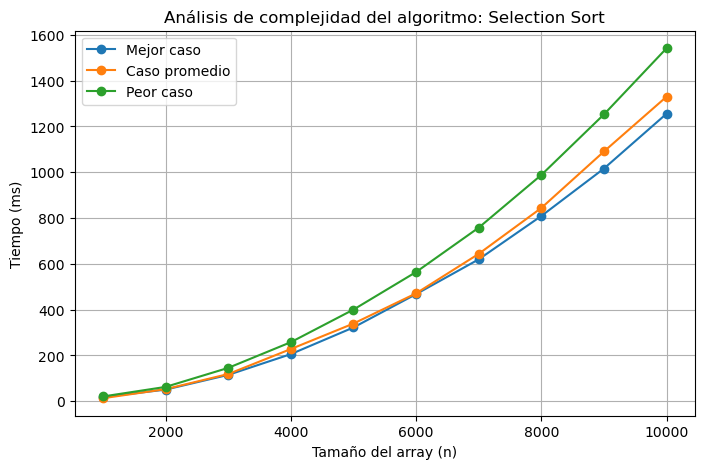

In [59]:
graficar(tam, tiem_mejor,tiem_prom, tiem_peor, "Selection Sort")

<h1>Ajuste de curva: Selection Sort<h1>

Mejor caso
Ajuste lineal: T(n) = 1.378740e-01n + -2.701075e+02
Ajuste cuadrático: T(n) = 1.218180e-05n^2 + 3.874253e-03n + -2.107925e+00



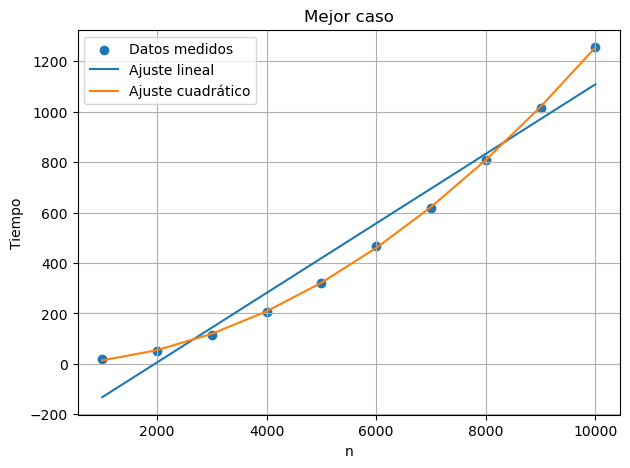

Caso promedio
Ajuste lineal: T(n) = 1.461589e-01n + -2.905696e+02
Ajuste cuadrático: T(n) = 1.335926e-05n^2 + -7.929470e-04n + 3.334152e+00



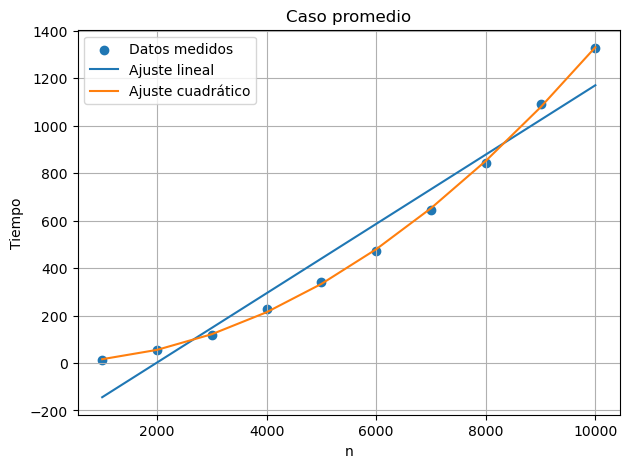

Peor caso
Ajuste lineal: T(n) = 1.690184e-01n + -3.302645e+02
Ajuste cuadrático: T(n) = 1.501643e-05n^2 + 3.837700e-03n + 9.699700e-02



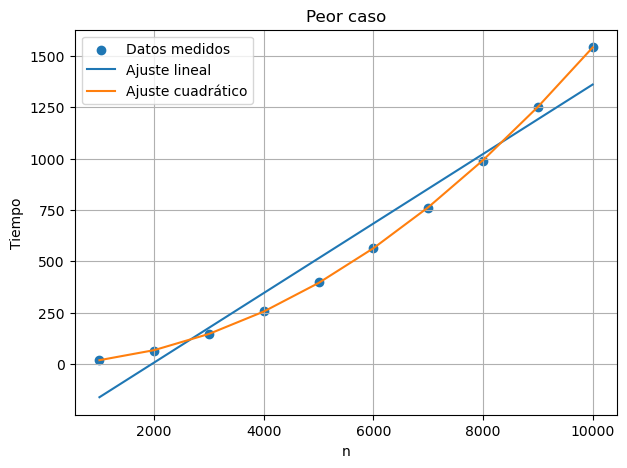

In [60]:

n = np.array(tam)

casos = {
    "Mejor caso": np.array(tiem_mejor),
    "Caso promedio": np.array(tiem_prom),
    "Peor caso": np.array(tiem_peor)
}

for nombre, t in casos.items():

    coef_lin = np.polyfit(n, t, 1)
    a, b = coef_lin
    T_lin = a*n + b

    coef_cuad = np.polyfit(n, t, 2)
    a2, b2, c2 = coef_cuad
    T_cuad = a2*n**2 + b2*n + c2

    print(nombre)
    print(f"Ajuste lineal: T(n) = {a:.6e}n + {b:.6e}")
    print(f"Ajuste cuadrático: T(n) = {a2:.6e}n^2 + {b2:.6e}n + {c2:.6e}")
    print()

    plt.figure(figsize=(7,5))

    plt.scatter(n, t, label="Datos medidos")
    plt.plot(n, T_lin, label="Ajuste lineal")
    plt.plot(n, T_cuad, label="Ajuste cuadrático")

    plt.xlabel("n")
    plt.ylabel("Tiempo")
    plt.title(nombre)

    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
tam = []
tiem_mejor = []
tiem_prom = []
tiem_peor = []

for n in range(1, 11):

    size = n * 1000
    tam.append(size)

    _, t_mejor = SELECTION_SORT(creacion_muestra_mejor_caso(size))
    _, t_peor = SELECTION_SORT(creacion_muestra_peor_caso(size))
    _, t_prom = SELECTION_SORT(creacion_muestras_caso_promedio(size))

    tiem_mejor.append(t_mejor)
    tiem_peor.append(t_peor)
    tiem_prom.append(t_prom)

print(f"{'Tam':<10}{'Mejor Caso':<15}{'Promedio':<15}{'Peor Caso':<15}")
for t, mejor, prom, peor in zip(tam, tiem_mejor, tiem_prom, tiem_peor):
    print(f"{t:<10}{mejor:<15.6f}{prom:<15.6f}{peor:<15.6f}")

Tam       Mejor Caso     Promedio       Peor Caso      
5000      190.462873     192.255295     225.529293     
10000     739.566230     779.229688     909.393255     
15000     1673.824494    1766.851216    2015.061959    
20000     2931.918543    3177.753526    3661.268570    
25000     4708.272950    5188.605431    5732.798526    
30000     7094.250234    7572.937846    8574.309715    
35000     9196.176979    10298.259387   11239.315104   
40000     12093.194307   13627.220009   14758.754320   
45000     15382.157566   17778.517197   18781.569183   
50000     19484.509068   22936.839998   23146.722581   


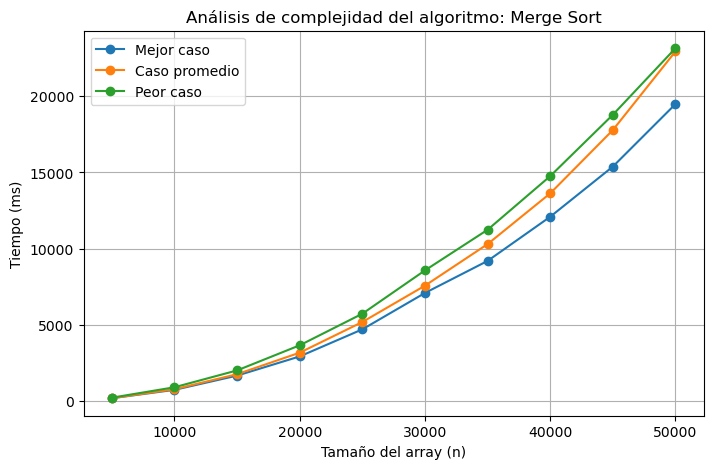

In [23]:
graficar(tam, tiem_mejor,tiem_prom, tiem_peor, "Merge Sort")

<h1>Determinar la funcion T(n)<h1>

El algoritmo siempre revisa todos los elementos restantes para encontrar el minimo
entonces:
$(n - 1) + (n - 2) + ... + 1$
esta suma es:
$(n*(n-1))/2$

<h1>Graficacion de Funciones<h1>

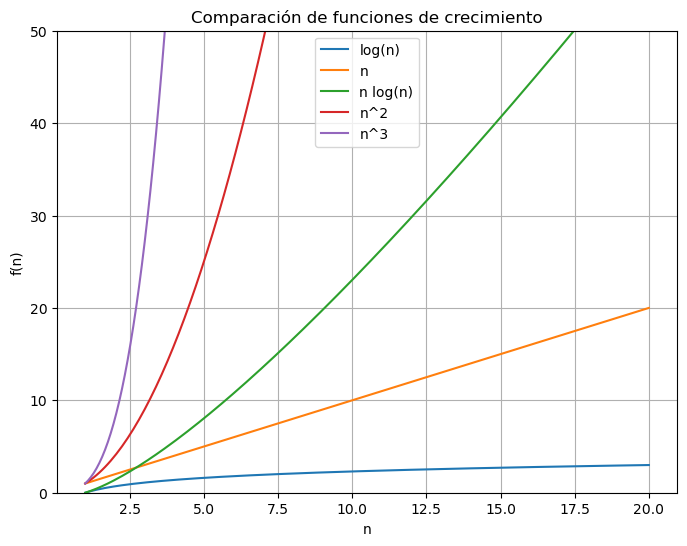

In [48]:
n = np.linspace(1, 20, 200)

plt.figure(figsize=(8,6))

plt.plot(n, np.log(n), label="log(n)")
plt.plot(n, n, label="n")
plt.plot(n, n*np.log(n), label="n log(n)")
plt.plot(n, n**2, label="n^2")
plt.plot(n, n**3, label="n^3")

plt.xlabel("n")
plt.ylabel("f(n)")
plt.title("Comparación de funciones de crecimiento")

plt.ylim(0,50)  

plt.legend()
plt.grid(True)

plt.show()